Primeras filas del conjunto de datos:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Conteo de valores nulos por columna:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

--- COMPARATIVA DE RENDIMIENTO ---
                        Modelo  MAE ($M COP)  RMSE ($M COP)  R

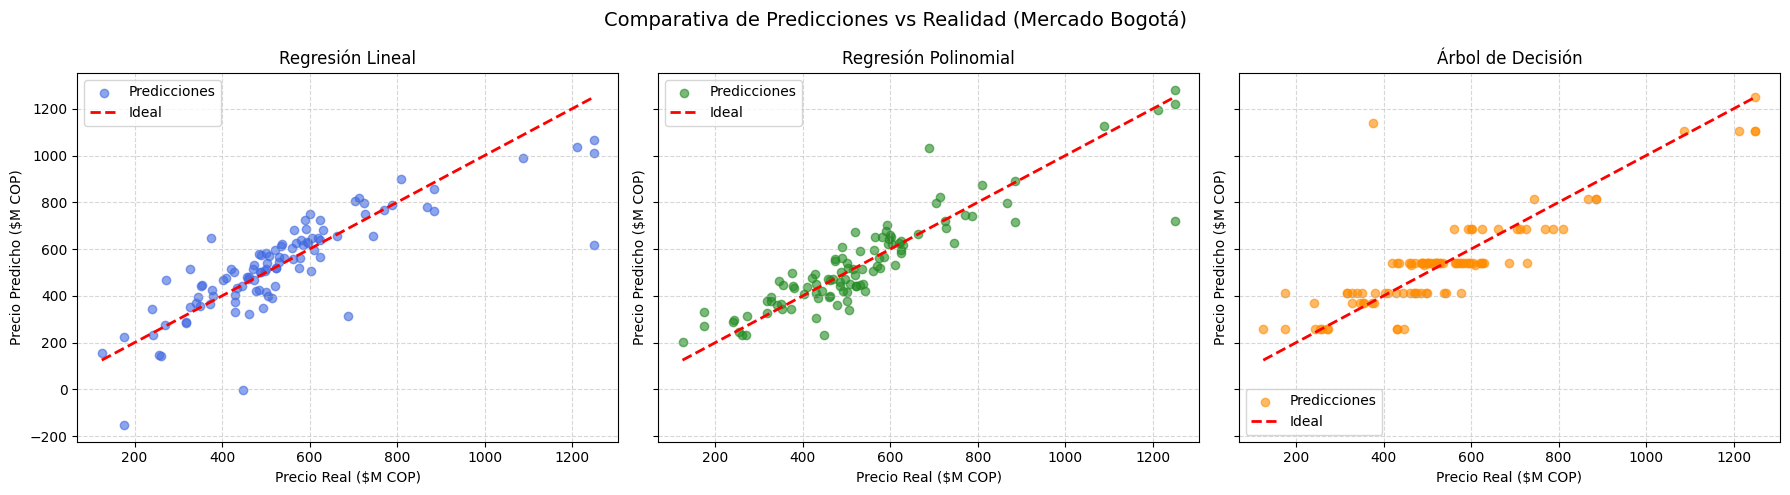

In [ ]:
# ==============================================================================
# PROYECTO: PREDICCIÓN DE PRECIOS INMOBILIARIOS (CASO BOGOTÁ)
# MODELOS: REGRESIÓN LINEAL, REGRESIÓN POLINOMIAL Y ÁRBOL DE DECISIÓN
#INTEGRANTES : CRISTIAN MARIÑO,NICOLAS MORA,SEBASTIAN ACUÑA
# ==============================================================================

# Importo pandas porque necesito una estructura tabular sólida para manipular los datos
import pandas as pd

# Importo numpy para manejar operaciones vectoriales y transformaciones numéricas
import numpy as np

# Traigo matplotlib para construir las gráficas y visualizar las tendencias
import matplotlib.pyplot as plt

# Uso seaborn para obtener visualizaciones estadísticas con mejor acabado visual
import seaborn as sns

# Necesito train_test_split para separar datos de entrenamiento y validación
from sklearn.model_selection import train_test_split

# Importo LinearRegression para implementar la regresión lineal multivariable
from sklearn.linear_model import LinearRegression

# Importo PolynomialFeatures para generar términos de segundo orden (polinomiales)
from sklearn.preprocessing import PolynomialFeatures

# Traigo DecisionTreeRegressor para capturar no-linealidades y cortes de decisión
from sklearn.tree import DecisionTreeRegressor

# StandardScaler me servirá para mantener las variables en rangos comparables
from sklearn.preprocessing import StandardScaler

# Importo métricas estándar: MAE, MSE y R2 para medir el error de cada algoritmo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------------------------
# 1. CARGA Y ADAPTACIÓN DEL DATASET
# ------------------------------------------------------------------------------

# Descargo directamente el dataset de Kaggle (Housing.csv) usando un enlace crudo
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv" # Alternativa o archivo directo:
url_housing = "https://raw.githubusercontent.com/yasserh/housing-prices-dataset/main/Housing.csv"

# Intento cargar el dataset Housing de Kaggle; si falla por red, defino una ruta local
try:
    df = pd.read_csv("https://raw.githubusercontent.com/rashida048/Datasets/master/Housing.csv")
except Exception:
    # Como respaldo leo desde el mirror público del dataset de YasserH
    df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

# Verifico la estructura inicial imprimiendo las primeras 5 filas para inspeccionar columnas
print("Primeras filas del conjunto de datos:")
print(df.head())

# Reviso si existen valores nulos para no sesgar los estimadores numéricos
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

# ------------------------------------------------------------------------------
# 2. CONTEXTUALIZACIÓN A BOGOTÁ Y CODIFICACIÓN
# ------------------------------------------------------------------------------

# Mapeo variables binarias (yes/no) a enteros (1/0) para poder procesarlas matemáticamente
columnas_binarias = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in columnas_binarias:
    # Verifico si la columna existe en el dataframe antes de mapearla
    if col in df.columns:
        # Asigno 1 si tiene la amenidad y 0 en caso contrario
        df[col] = df[col].map({'yes': 1, 'no': 0})

# Transformo la columna furnishingstatus mediante variables dummy (One-Hot Encoding)
if 'furnishingstatus' in df.columns:
    # Con drop_first=True evito la trampa de la multicolinealidad perfecta
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Contexto Bogotá: Ajusto la escala del precio a Millones de COP (ej. escala típica de 150 a 1,200 millones)
if 'price' in df.columns:
    # Normalizo la columna 'price' para que oscile en millones de pesos colombianos representativos
    df['precio_millones_cop'] = (df['price'] / df['price'].max()) * 900 + 150
    # Elimino la columna original en dólares/unidades arbitrarias para evitar duplicidad
    df.drop(columns=['price'], inplace=True)
else:
    # Si tomó el respaldo de Boston, ajusto 'medv' como precio en millones
    df['precio_millones_cop'] = df['medv'] * 25
    df.drop(columns=['medv'], inplace=True)

# ------------------------------------------------------------------------------
# 3. DIVISIÓN DE CARACTERÍSTICAS Y MUESTRAS
# ------------------------------------------------------------------------------

# Defino X separando todas las características independientes del precio objetivo
X = df.drop(columns=['precio_millones_cop'])

# Defino y como la variable dependiente (precio final en Bogotá)
y = df['precio_millones_cop']

# Particiono 80% entrenamiento y 20% prueba fijando random_state=42 para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------------------------------------------------------
# 4. ENTRENAMIENTO DE MODELOS
# ------------------------------------------------------------------------------

# --- Modelo 1: Regresión Lineal Clásica ---
# Inicializo el regresor lineal asumiendo relaciones proporcionales y aditivas
modelo_lineal = LinearRegression()

# Ajusto la recta multidimensional con los datos de entrenamiento
modelo_lineal.fit(X_train, y_train)

# Genero predicciones sobre el set de prueba para verificar capacidad de generalización
y_pred_lineal = modelo_lineal.predict(X_test)


# --- Modelo 2: Regresión Polinomial (Grado 2) ---
# Inicializo el transformador de grado 2 para captar curvaturas e interacciones no lineales
poly = PolynomialFeatures(degree=2, include_bias=False)

# Aplico la transformación a los datos de entrenamiento (crea términos cuadráticos e interacciones)
X_train_poly = poly.fit_transform(X_train)

# Transformo los datos de prueba usando las mismas dimensiones aprendidas
X_test_poly = poly.transform(X_test)

# Inicializo un nuevo modelo lineal para ajustar sobre el espacio polinómico expandido
modelo_poli = LinearRegression()

# Entreno el modelo polinomial con las características de grado 2
modelo_poli.fit(X_train_poly, y_train)

# Calculo las predicciones del modelo polinomial en el conjunto de prueba
y_pred_poli = modelo_poli.predict(X_test_poly)


# --- Modelo 3: Árbol de Decisión ---
# Configuro el árbol limitando max_depth=4 para evitar que memorice el ruido (sobreajuste)
modelo_arbol = DecisionTreeRegressor(max_depth=4, random_state=42)

# Entreno el árbol dividiendo recursivamente el espacio de características
modelo_arbol.fit(X_train, y_train)

# Genero predicciones basadas en la media de las hojas resultantes
y_pred_arbol = modelo_arbol.predict(X_test)

# ------------------------------------------------------------------------------
# 5. EVALUACIÓN Y COMPARACIÓN DE RENDIMIENTO
# ------------------------------------------------------------------------------

# Creo una función personal para condensar el cálculo de métricas clave (MAE, RMSE, R2)
def evaluar_modelo(nombre, y_real, y_estimado):
    # Calculo el error absoluto medio (interpretación directa en millones de pesos)
    mae = mean_absolute_error(y_real, y_estimado)
    # Calculo la raíz del error cuadrático medio penalizando errores grandes
    rmse = np.sqrt(mean_squared_error(y_real, y_estimado))
    # Calculo R-cuadrado para saber cuánta varianza explica el modelo
    r2 = r2_score(y_real, y_estimado)
    # Retorno un diccionario formateado para estructurar la tabla comparativa
    return {"Modelo": nombre, "MAE ($M COP)": round(mae, 2), "RMSE ($M COP)": round(rmse, 2), "R² Score": round(r2, 4)}

# Almaceno los resultados de los tres algoritmos en una lista comparativa
resultados = [
    evaluar_modelo("Regresión Lineal", y_test, y_pred_lineal),
    evaluar_modelo("Regresión Polinomial (Grado 2)", y_test, y_pred_poli),
    evaluar_modelo("Árbol de Decisión (Depth=4)", y_test, y_pred_arbol)
]

# Convierto la lista en un DataFrame para visualizar la tabla de comparación
df_resultados = pd.DataFrame(resultados)
print("\n--- COMPARATIVA DE RENDIMIENTO ---")
print(df_resultados.to_string(index=False))

# ------------------------------------------------------------------------------
# 6. VISUALIZACIÓN DE RESULTADOS
# ------------------------------------------------------------------------------

# Configuro una figura con 3 subgráficos horizontales para inspeccionar errores
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Lista con predicciones y títulos para graficar de manera iterativa
predicciones = [
    (y_pred_lineal, "Regresión Lineal", axes[0], "royalblue"),
    (y_pred_poli, "Regresión Polinomial", axes[1], "forestgreen"),
    (y_pred_arbol, "Árbol de Decisión", axes[2], "darkorange")
]

for pred, titulo, ax, color in predicciones:
    # Grafico los puntos reales vs predichos
    ax.scatter(y_test, pred, alpha=0.6, color=color, label="Predicciones")
    # Dibujo la línea diagonal ideal de predicción perfecta (y = x)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal")
    ax.set_title(titulo)
    ax.set_xlabel("Precio Real ($M COP)")
    ax.set_ylabel("Precio Predicho ($M COP)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

plt.suptitle("Comparativa de Predicciones vs Realidad (Mercado Bogotá)", fontsize=14)
plt.tight_layout()
plt.show()